# Part 1: ERP pipeline

Raw EEG from the MNE `sample` dataset turned into averaged responses to sounds and images.
One subject, 60 EEG channels (the file also has MEG which I drop), with auditory and visual stimuli presented left or right.

Steps: load, average reference, band-pass 0.1 to 40 Hz, find events, epoch from -200 to 500 ms, reject noisy trials, average per condition.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

mne.set_log_level("WARNING")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

## Load and preprocess

In [2]:
path = mne.datasets.sample.data_path()
raw_orig = mne.io.read_raw_fif(path / "MEG" / "sample" / "sample_audvis_raw.fif", preload=True)
raw_orig.pick(["eeg", "eog", "stim"])  # drop MEG

raw = raw_orig.copy()
raw.set_eeg_reference("average", projection=True)
raw.filter(l_freq=0.1, h_freq=40.0)
print(raw)
print("bad channels:", raw.info["bads"])

<Raw | sample_audvis_raw.fif, 70 x 166800 (277.7 s), ~92.0 MiB, data loaded>
bad channels: ['EEG 053']


In [3]:
events = mne.find_events(raw, stim_channel="STI 014")
event_id = {"auditory/left": 1, "auditory/right": 2,
            "visual/left": 3, "visual/right": 4}
print(len(events), "events total")

320 events total


## Epoch and reject noisy trials

In [4]:
reject = dict(eeg=150e-6, eog=250e-6)  # volts
epochs = mne.Epochs(raw, events, event_id, tmin=-0.2, tmax=0.5,
                    baseline=(None, 0), reject=reject, preload=True)
print(epochs)

n_events = {k: int((events[:, 2] == v).sum()) for k, v in event_id.items()}
kept = {k: len(epochs[k]) for k in event_id}
pd.DataFrame({"events": n_events, "kept": kept}).assign(dropped=lambda d: d.events - d.kept)

<Epochs | 278 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~65.5 MiB, data loaded,
 'auditory/left': 67
 'auditory/right': 71
 'visual/left': 73
 'visual/right': 67>


,events,kept,dropped
auditory/left,72,67,5
auditory/right,73,71,2
visual/left,73,73,0
visual/right,71,67,4


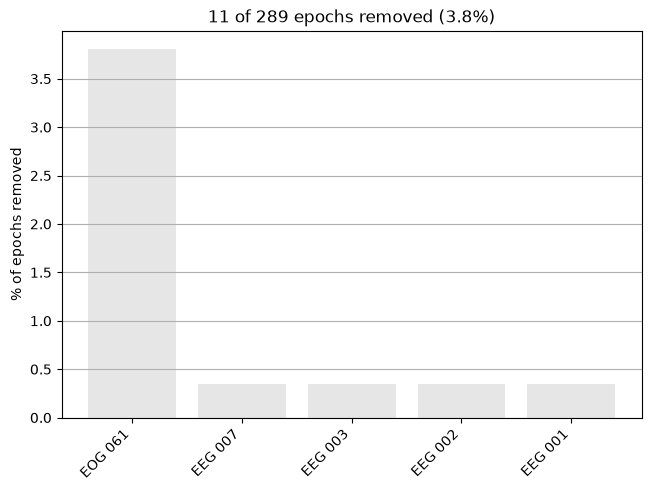

In [5]:
fig = epochs.plot_drop_log(show=False)

## Average and plot

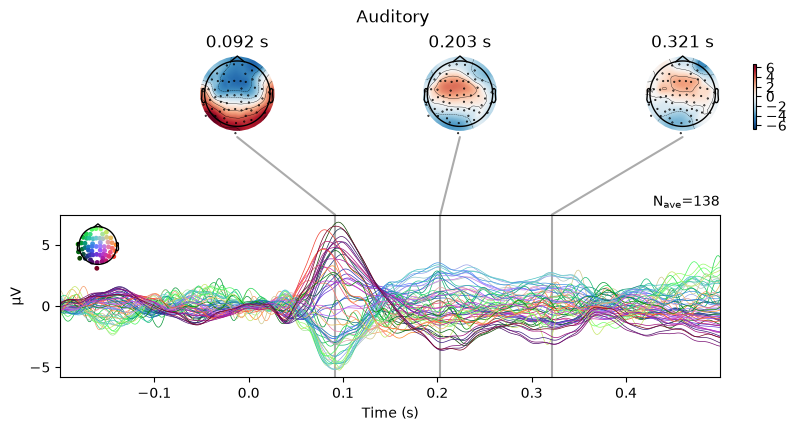

In [6]:
aud = epochs["auditory"].average()
vis = epochs["visual"].average()

fig = aud.plot_joint(title="Auditory", show=False)
fig.savefig(FIG / "erp_auditory_joint.png", dpi=120, bbox_inches="tight")

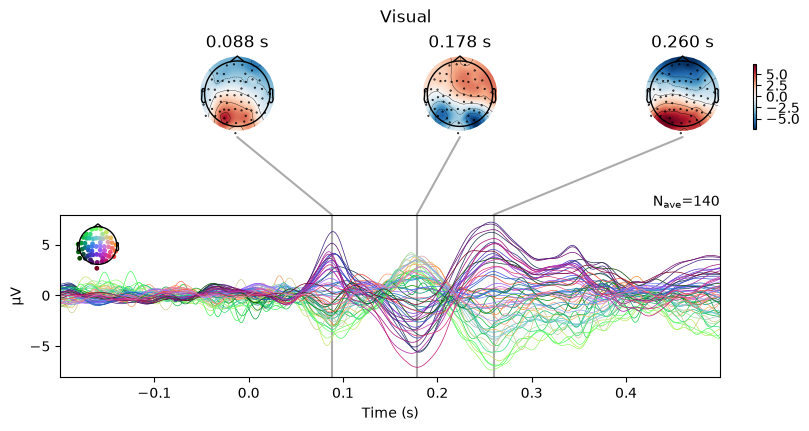

In [7]:
fig = vis.plot_joint(title="Visual", show=False)
fig.savefig(FIG / "erp_visual_joint.png", dpi=120, bbox_inches="tight")

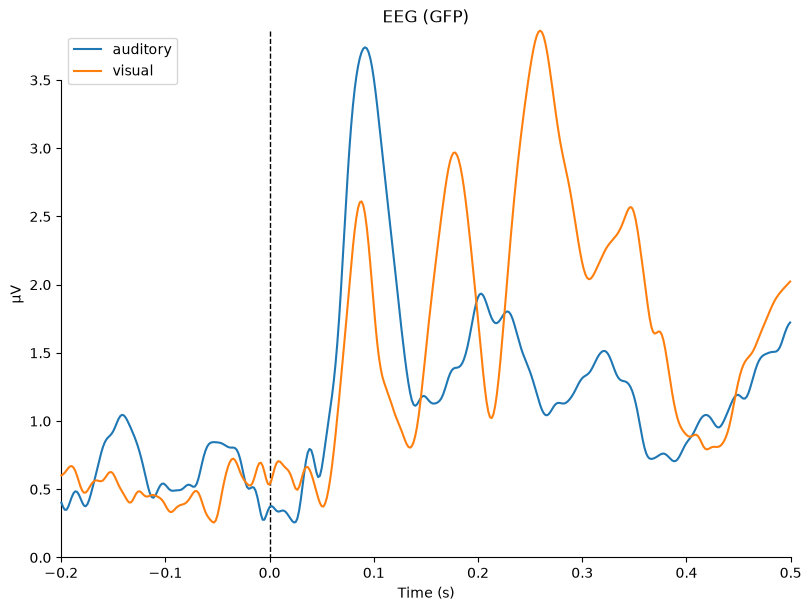

In [8]:
figs = mne.viz.plot_compare_evokeds({"auditory": aud, "visual": vis},
                                    picks="eeg", combine="gfp", show=False)
figs[0].savefig(FIG / "erp_gfp_compare.png", dpi=120, bbox_inches="tight")

## Checking the peaks

The auditory response should have an N100 around 100 ms over central electrodes, and the visual response should show up over the back of the head.

In [9]:
ch, lat, amp = aud.get_peak(ch_type="eeg", tmin=0.07, tmax=0.15, mode="neg", return_amplitude=True)
print(f"auditory N100: {ch} at {lat*1000:.0f} ms, {amp*1e6:.1f} uV")

ch, lat, amp = vis.get_peak(ch_type="eeg", tmin=0.07, tmax=0.2, return_amplitude=True)
print(f"visual peak:   {ch} at {lat*1000:.0f} ms, {amp*1e6:.1f} uV")

auditory N100: EEG 007 at 97 ms, -5.2 uV
visual peak:   EEG 056 at 178 ms, -7.1 uV


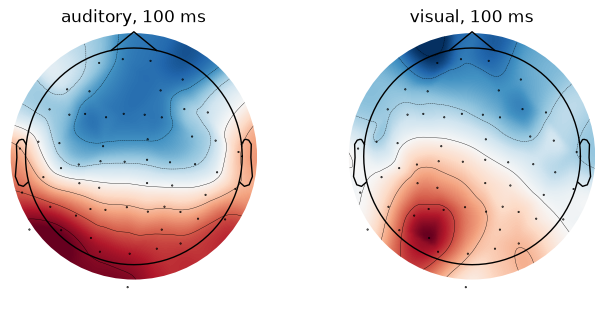

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
aud.plot_topomap(times=[0.1], axes=axes[0], colorbar=False, show=False)
vis.plot_topomap(times=[0.1], axes=axes[1], colorbar=False, show=False)
axes[0].set_title("auditory, 100 ms")
axes[1].set_title("visual, 100 ms")
fig.savefig(FIG / "erp_topomaps_100ms.png", dpi=120, bbox_inches="tight")

## Varying the preprocessing

Same pipeline with a different high-pass (0.1 vs 1 Hz) and different rejection thresholds, to see how trial counts and the auditory peak change.

In [11]:
def run(l_freq, reject):
    r = raw_orig.copy()
    r.set_eeg_reference("average", projection=True)
    r.filter(l_freq=l_freq, h_freq=40.0)
    ep = mne.Epochs(r, events, event_id, tmin=-0.2, tmax=0.5,
                    baseline=(None, 0), reject=reject, preload=True)
    a = ep["auditory"].average()
    _, lat, amp = a.get_peak(ch_type="eeg", tmin=0.07, tmax=0.15, mode="neg", return_amplitude=True)
    return ep, a, dict(aud_trials=len(ep["auditory"]), vis_trials=len(ep["visual"]),
                       n100_ms=round(lat * 1000), n100_uV=round(amp * 1e6, 2))

settings = {
    "0.1-40 Hz, eeg 150 / eog 250": (0.1, dict(eeg=150e-6, eog=250e-6)),
    "1-40 Hz, eeg 150 / eog 250":   (1.0, dict(eeg=150e-6, eog=250e-6)),
    "0.1-40 Hz, eeg 100 / eog 150": (0.1, dict(eeg=100e-6, eog=150e-6)),
    "0.1-40 Hz, eeg 150 only":      (0.1, dict(eeg=150e-6)),
    "0.1-40 Hz, no rejection":      (0.1, None),
}
results, aud_versions = {}, {}
for name, (lf, rej) in settings.items():
    _, a, row = run(lf, rej)
    results[name] = row
    aud_versions[name] = a

pd.DataFrame.from_dict(results, orient="index")

,aud_trials,vis_trials,n100_ms,n100_uV
"0.1-40 Hz, eeg 150 / eog 250",138,140,97,-5.24
"1-40 Hz, eeg 150 / eog 250",138,140,92,-5.33
"0.1-40 Hz, eeg 100 / eog 150",115,118,93,-4.83
"0.1-40 Hz, eeg 150 only",144,144,97,-5.88
"0.1-40 Hz, no rejection",145,144,97,-6.40


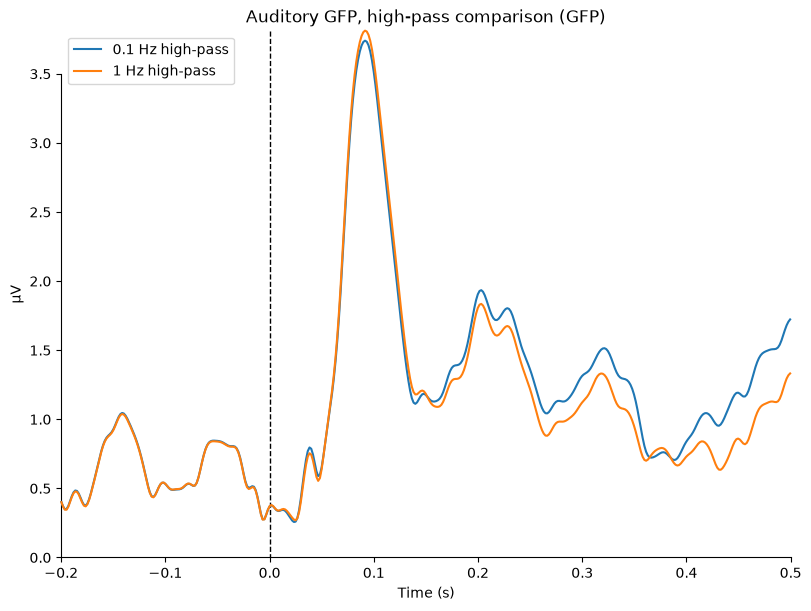

In [12]:
figs = mne.viz.plot_compare_evokeds(
    {"0.1 Hz high-pass": aud_versions["0.1-40 Hz, eeg 150 / eog 250"],
     "1 Hz high-pass": aud_versions["1-40 Hz, eeg 150 / eog 250"]},
    picks="eeg", combine="gfp", title="Auditory GFP, high-pass comparison", show=False)
figs[0].savefig(FIG / "erp_highpass_compare.png", dpi=120, bbox_inches="tight")

## ICA for eye blinks

Instead of throwing away every trial with a blink, fit ICA, find the component that tracks the EOG channel and subtract it.
ICA is fit on a 1 Hz high-passed copy since it fits better without slow drift, then applied to the 0.1 Hz data.

In [13]:
from mne.preprocessing import ICA

raw_ica = raw.copy()
raw_ica.apply_proj()  # apply the average reference before ICA
raw_hp = raw_ica.copy().filter(l_freq=1.0, h_freq=None)

ica = ICA(n_components=20, random_state=97)
ica.fit(raw_hp)

eog_idx, scores = ica.find_bads_eog(raw_ica)
print("EOG components:", [int(i) for i in eog_idx])

EOG components: [0]


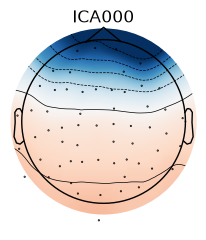

In [14]:
fig = ica.plot_components(picks=eog_idx, show=False)
fig = fig[0] if isinstance(fig, list) else fig
fig.savefig(FIG / "ica_eog_components.png", dpi=120, bbox_inches="tight")

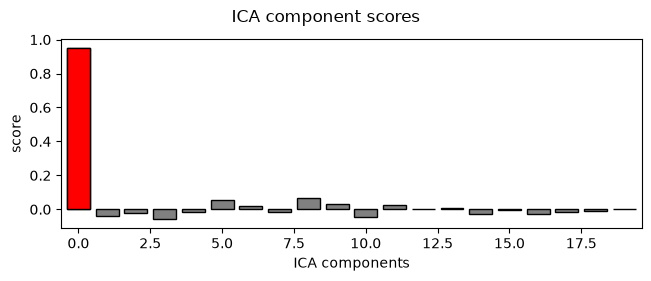

In [15]:
fig = ica.plot_scores(scores, exclude=eog_idx, show=False)

In [16]:
ica.exclude = eog_idx
raw_clean = ica.apply(raw_ica.copy())

def count(r, reject):
    ep = mne.Epochs(r, events, event_id, tmin=-0.2, tmax=0.5,
                    baseline=(None, 0), reject=reject, preload=True)
    return ep, dict(auditory=len(ep["auditory"]), visual=len(ep["visual"]), total=len(ep))

_, no_ica = count(raw, dict(eeg=150e-6, eog=250e-6))
_, ica_eog = count(raw_clean, dict(eeg=150e-6, eog=250e-6))
epochs_ica, ica_eeg = count(raw_clean, dict(eeg=150e-6))

pd.DataFrame({
    "no ICA, eeg + eog reject": no_ica,
    "ICA, eeg + eog reject": ica_eog,
    "ICA, eeg reject only": ica_eeg,
}).T

,auditory,visual,total
"no ICA, eeg + eog reject",138,140,278
"ICA, eeg + eog reject",138,140,278
"ICA, eeg reject only",145,144,289


Keeping the EOG threshold after ICA doesn't make sense, because the EOG channel itself still has the blinks in it (ICA only cleans the EEG channels).
So the fair comparison is no ICA with the EOG rule vs ICA with only the EEG rule.

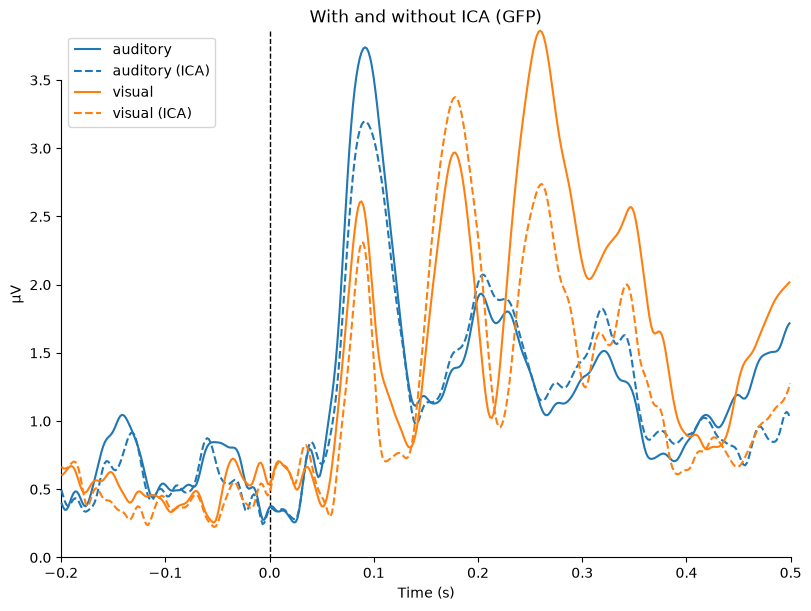

In [17]:
aud_ica = epochs_ica["auditory"].average()
vis_ica = epochs_ica["visual"].average()
figs = mne.viz.plot_compare_evokeds(
    {"auditory": aud, "auditory (ICA)": aud_ica, "visual": vis, "visual (ICA)": vis_ica},
    picks="eeg", combine="gfp", title="With and without ICA",
    colors=["C0", "C0", "C1", "C1"], linestyles=["-", "--", "-", "--"], show=False)
figs[0].savefig(FIG / "erp_ica_compare.png", dpi=120, bbox_inches="tight")